# Q2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [2]:
wine_df = pd.read_csv("winequality-red.csv", sep=";")
wine_df["binary_quality"] = np.where(wine_df["quality"] > 5, 0, 1)
features = wine_df.drop(columns=["quality", "binary_quality"])
labels = wine_df["binary_quality"]
X = features.values
y = labels.values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.40, random_state=42
)

## 2.1

In [3]:
decision_tree_model = DecisionTreeClassifier(max_depth=12, random_state=0)
decision_tree_model.fit(X_train, y_train)
train_predictions = decision_tree_model.predict(X_train)
test_predictions  = decision_tree_model.predict(X_test)
train_acc_dt = accuracy_score(y_train, train_predictions)
test_acc_dt  = accuracy_score(y_test, test_predictions)
print(f"Decision Tree - Training Accuracy: {train_acc_dt:.4f}")
print(f"Decision Tree - Test Accuracy: {test_acc_dt:.4f}")


Decision Tree - Training Accuracy: 0.9896
Decision Tree - Test Accuracy: 0.7281


## 2.2

In [4]:
rf_model = RandomForestClassifier(n_estimators=100,max_depth=12,random_state=0)
rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_test_pred  = rf_model.predict(X_test)
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc  = accuracy_score(y_test, rf_test_pred)
print(f"Random Forest (100 trees) - Train Accuracy: {rf_train_acc:.3f}")
print(f"Random Forest (100 trees) - Test Accuracy:  {rf_test_acc:.3f}")


Random Forest (100 trees) - Train Accuracy: 0.999
Random Forest (100 trees) - Test Accuracy:  0.802


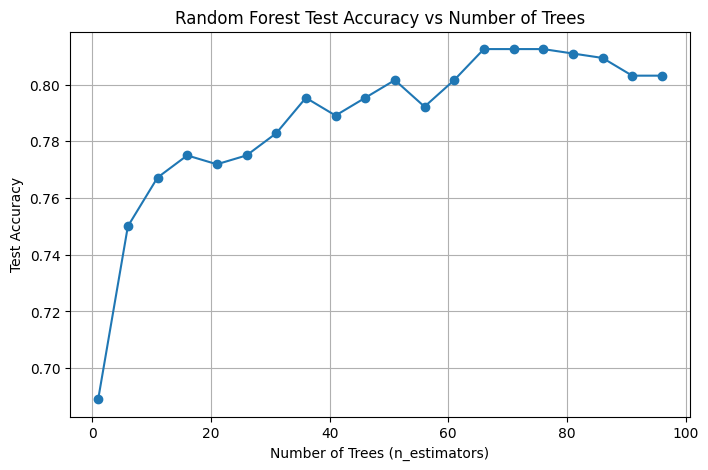

In [5]:
tree_counts = range(1, 101,5)
test_accuracies = []
for k in tree_counts:
    rf_tmp = RandomForestClassifier(
        n_estimators=k,
        max_depth=12,
        random_state=0
    )
    rf_tmp.fit(X_train, y_train)
    preds = rf_tmp.predict(X_test)
    test_accuracies.append(accuracy_score(y_test, preds))
plt.figure(figsize=(8, 5))
plt.plot(tree_counts, test_accuracies, marker='o')
plt.title("Random Forest Test Accuracy vs Number of Trees")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()


## 2.3

In [6]:
rf_full_features = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    max_features=11,
    random_state=0
)
rf_full_features.fit(X_train, y_train)
train_pred_full = rf_full_features.predict(X_train)
test_pred_full  = rf_full_features.predict(X_test)
train_acc_full = accuracy_score(y_train, train_pred_full)
test_acc_full  = accuracy_score(y_test, test_pred_full)
print("Random Forest (no feature randomness)")
print(f"Training Accuracy: {train_acc_full:.3f}")
print(f"Test Accuracy:     {test_acc_full:.3f}")


Random Forest (no feature randomness)
Training Accuracy: 0.999
Test Accuracy:     0.786


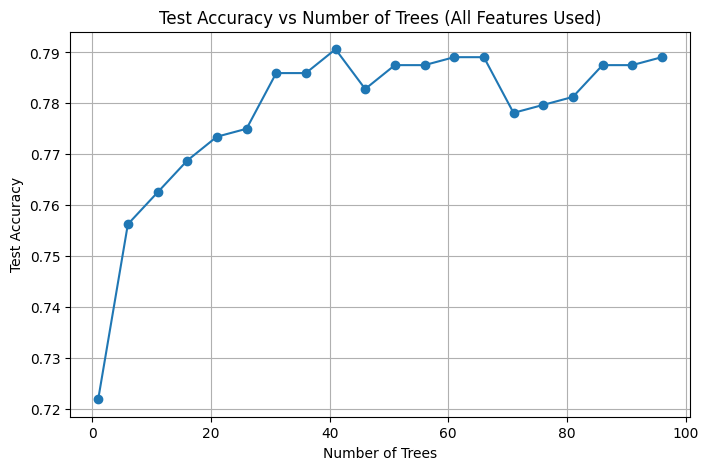

In [7]:
num_trees = range(1, 101, 5)
test_acc_curve = []
for trees in num_trees:
    rf_tmp = RandomForestClassifier(
        n_estimators=trees,
        max_depth=12,
        max_features=11,
        random_state=0
    )
    rf_tmp.fit(X_train, y_train)
    y_pred_tmp = rf_tmp.predict(X_test)
    test_acc_curve.append(accuracy_score(y_test, y_pred_tmp))
plt.figure(figsize=(8, 5))
plt.plot(num_trees, test_acc_curve, marker='o')
plt.title("Test Accuracy vs Number of Trees (All Features Used)")
plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()


## 2.4.a

The model in section (b) is better than the model in section (a) because it uses stronger regularization. Instead of relying on a single decision tree, it uses bootstrapping together with 100 trees, which improves the model's ability to generalize.

## 2.4.b

The model in section (c) is worse than the model in section (b) because it does not prevent overfitting. It uses all features at every split instead of using the square root of the number of features, which is the library default and usually provides better regularization.